# Handwritten Digit Recognition Using Deep Learning

## Project Overview

This project demonstrates the use of Deep Learning and Convolutional Neural Networks (CNNs) to recognize handwritten digits. The model is trained using the MNIST dataset, which contains grayscale images of handwritten digits from 0 to 9.

The objective of the project is to build a classification model that can accurately identify handwritten digits from image data.

## Technologies Used

- Python
- NumPy
- Matplotlib
- TensorFlow
- Keras
- Scikit-learn

## Dataset

The MNIST dataset contains handwritten digit images belonging to 10 classes, representing the digits 0 through 9. Each image is 28 × 28 pixels and contains grayscale pixel values.

## Learning Outcomes

- Understanding image classification
- Working with the MNIST dataset
- Image preprocessing and normalization
- Building a Convolutional Neural Network
- Training and evaluating a Deep Learning model
- Making predictions on unseen handwritten digit images

In [2]:
import sys
!{sys.executable} -m pip install tensorflow numpy matplotlib scikit-learn pandas


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\bhavc\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("All libraries imported successfully!")
print("TensorFlow version:", tf.__version__)

All libraries imported successfully!
TensorFlow version: 2.21.0


In [2]:
# Load the MNIST handwritten digit dataset

(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print("Training images shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing images shape:", X_test.shape)
print("Testing labels shape:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 7s 1us/step
Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing images shape: (10000, 28, 28)
Testing labels shape: (10000,)


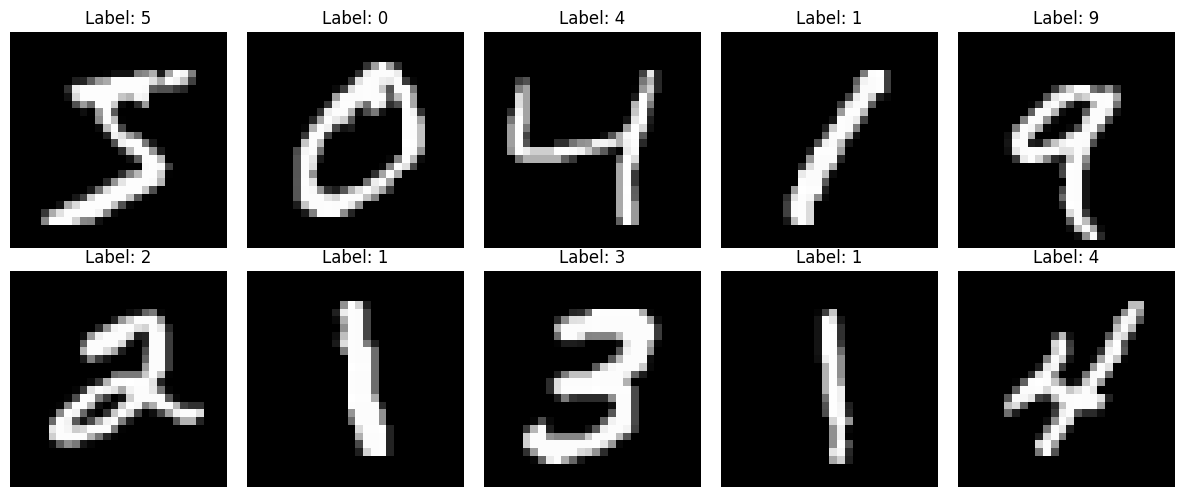

In [3]:
# Display sample handwritten digits

plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [4]:
# Normalize pixel values

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Training data normalized successfully!")
print("Pixel value range:", X_train.min(), "to", X_train.max())

Training data normalized successfully!
Pixel value range: 0.0 to 1.0


In [5]:
# Reshape images for CNN

X_train_cnn = X_train.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

print("Training data shape:", X_train_cnn.shape)
print("Testing data shape:", X_test_cnn.shape)

Training data shape: (60000, 28, 28, 1)
Testing data shape: (10000, 28, 28, 1)


In [6]:
# Build the Convolutional Neural Network (CNN)

model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu",
                  input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(10, activation="softmax")
])

model.summary()

C:\Users\bhavc\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Compile the CNN model

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [8]:
# Train the CNN model

history = model.fit(
    X_train_cnn,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 32s 68ms/step - accuracy: 0.9167 - loss: 0.2693 - val_accuracy: 0.9783 - val_loss: 0.0680
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 24s 57ms/step - accuracy: 0.9749 - loss: 0.0803 - val_accuracy: 0.9867 - val_loss: 0.0450
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 25s 60ms/step - accuracy: 0.9822 - loss: 0.0573 - val_accuracy: 0.9868 - val_loss: 0.0394
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 24s 58ms/step - accuracy: 0.9865 - loss: 0.0436 - val_accuracy: 0.9893 - val_loss: 0.0365
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 55ms/step - accuracy: 0.9885 - loss: 0.0375 - val_accuracy: 0.9882 - val_loss: 0.0394


In [9]:
# Evaluate the CNN model on the test dataset

test_loss, test_accuracy = model.evaluate(
    X_test_cnn,
    y_test,
    verbose=0
)

print("Test Accuracy:", round(test_accuracy * 100, 2), "%")
print("Test Loss:", round(test_loss, 4))

Test Accuracy: 98.71 %
Test Loss: 0.0374


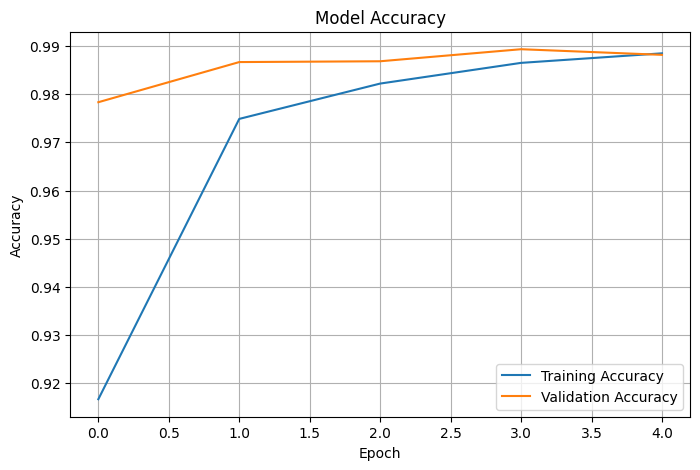

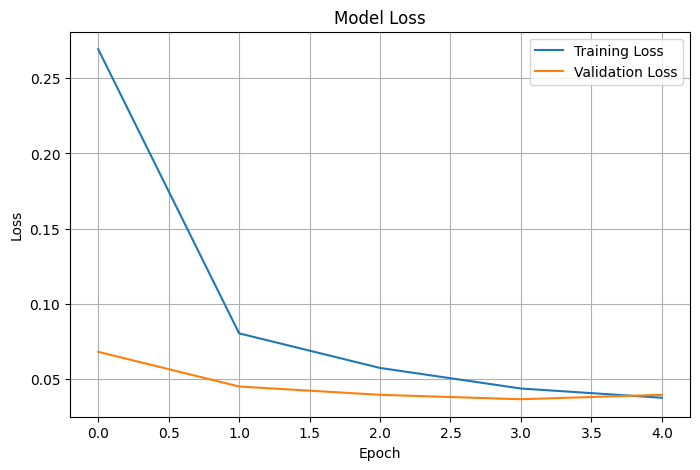

In [10]:
# Plot training and validation accuracy

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()


# Plot training and validation loss

plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


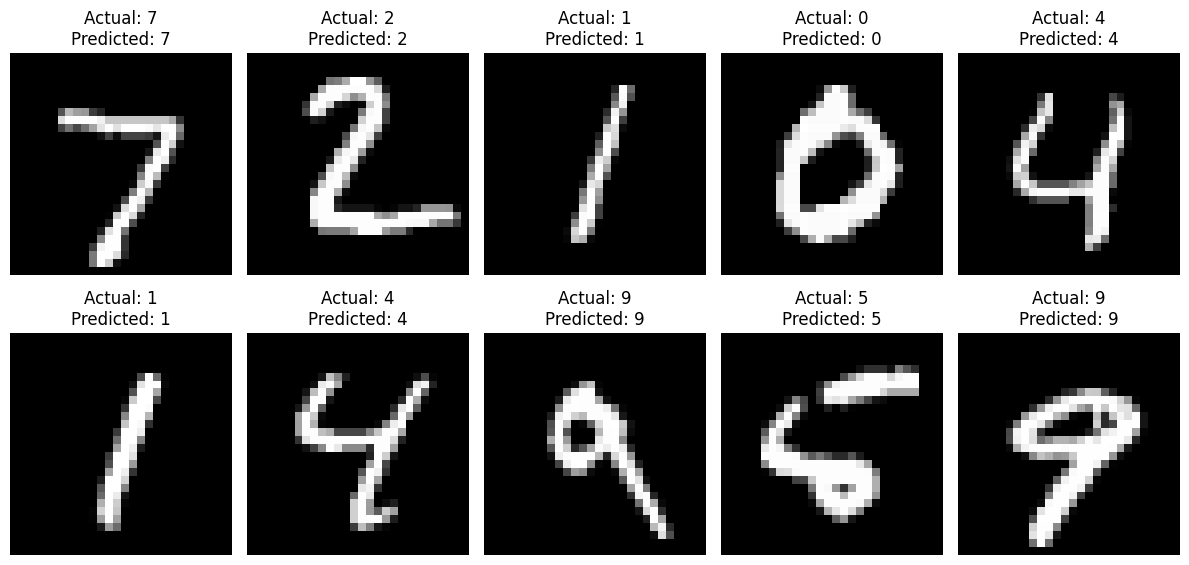

In [11]:
# Make predictions on test images

predictions = model.predict(X_test_cnn)

# Display sample predictions

plt.figure(figsize=(12, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    
    plt.imshow(X_test[i], cmap="gray")
    
    predicted_digit = np.argmax(predictions[i])
    actual_digit = y_test[i]
    
    plt.title(f"Actual: {actual_digit}\nPredicted: {predicted_digit}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [12]:
# Generate predictions for the complete test dataset

y_pred = model.predict(X_test_cnn)
y_pred_classes = np.argmax(y_pred, axis=1)

# Classification Report

print("Classification Report:")
print(classification_report(y_test, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       1.00      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       1.00      0.98      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.97      0.99      0.98       892
           6       0.99      0.99      0.99       958
           7       0.96      1.00      0.98      1028
           8       0.99      0.98      0.99       974
           9       0.99      0.96      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



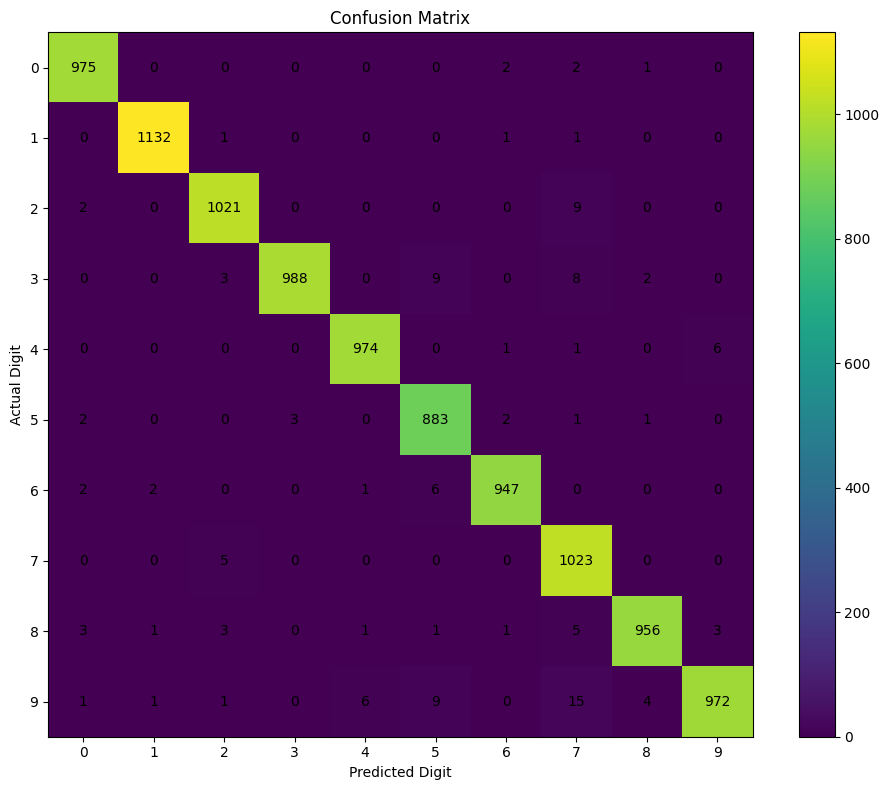

In [13]:
# Create and display the confusion matrix

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10, 8))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Digit")
plt.ylabel("Actual Digit")

plt.colorbar()

# Add digit labels
plt.xticks(range(10))
plt.yticks(range(10))

# Add numbers inside each cell
for i in range(10):
    for j in range(10):
        plt.text(
            j, i, str(cm[i, j]),
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [14]:
# Create a model performance metrics table

metrics_data = {
    "Metric": [
        "Training Accuracy",
        "Validation Accuracy",
        "Test Accuracy",
        "Test Loss"
    ],
    "Value": [
        f"{history.history['accuracy'][-1] * 100:.2f}%",
        f"{history.history['val_accuracy'][-1] * 100:.2f}%",
        f"{test_accuracy * 100:.2f}%",
        f"{test_loss:.4f}"
    ]
}

metrics_df = pd.DataFrame(metrics_data)

print("Model Performance Metrics:")
display(metrics_df)

Model Performance Metrics:


,Metric,Value
0,Training Accuracy,98.85%
1,Validation Accuracy,98.82%
2,Test Accuracy,98.71%
3,Test Loss,0.0374


In [15]:
# Save the trained CNN model

model.save("handwritten_digit_cnn.keras")

print("Trained model saved successfully as handwritten_digit_cnn.keras")

Trained model saved successfully as handwritten_digit_cnn.keras


## Steps Performed

1. Installed and imported the required Python libraries including NumPy, Pandas, Matplotlib, Scikit-learn, and TensorFlow.
2. Loaded the MNIST dataset containing handwritten digits from 0 to 9.
3. Explored the dataset and visualized sample handwritten digit images.
4. Normalized the pixel values from the range 0–255 to 0–1.
5. Reshaped the images to include a channel dimension for the CNN model.
6. Built a Convolutional Neural Network using Conv2D, MaxPooling, Flatten, Dense, and Dropout layers.
7. Compiled the model using the Adam optimizer and sparse categorical cross-entropy loss.
8. Trained the CNN model on the MNIST training dataset.
9. Evaluated the trained model on unseen test data.
10. Visualized training and validation accuracy and loss.
11. Generated predictions for sample handwritten digit images.
12. Generated a classification report and confusion matrix.
13. Created a model performance metrics table.
14. Saved the trained CNN model as `handwritten_digit_cnn.keras`.

## Key Features

- Handwritten digit recognition from 0 to 9
- MNIST dataset integration
- Image normalization and preprocessing
- Convolutional Neural Network (CNN)
- Training and validation performance visualization
- Test dataset evaluation
- Sample digit predictions
- Classification report
- Confusion matrix
- Model performance metrics table
- Saved trained model for future use

## Conclusion

This project demonstrates the practical implementation of Deep Learning for handwritten digit recognition. A Convolutional Neural Network was built and trained using the MNIST dataset to classify handwritten digits from 0 to 9.

The model was evaluated using unseen test images, and its performance was analyzed through accuracy, loss, a classification report, and a confusion matrix. Sample predictions also demonstrated the model's ability to correctly recognize handwritten digits.

This project shows how Convolutional Neural Networks can effectively learn image features and perform accurate image classification. Such technology can be applied in applications including automated form processing, postal code recognition, bank cheque processing, and other computer vision systems.